In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict
import json
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
load_dotenv()

True

In [3]:
gen_llm = ChatOllama(model= 'qwen3:0.6b', temperature=2)
#evl_llm = ChatOllama(model= 'qwen3:1.7b', temparature=0)
evl_llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash", temperature=0)

In [4]:
prompt = "write a short birthday wishing message"

In [5]:
response1 = gen_llm.invoke(prompt)
print(response1)


content="🎉 Happy Birthday! 🌟 How is life so美好的? Wishing you the most happiness and a sparkling day ahead! Happy birthday to everyone! 😊\n\nLet me know if you'd like a personal touch or a themed message! 😄" additional_kwargs={} response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-09-16T10:31:47.9395612Z', 'done': True, 'done_reason': 'stop', 'total_duration': 16612191000, 'load_duration': 12638500, 'prompt_eval_count': 16, 'prompt_eval_duration': 147880000, 'eval_count': 206, 'eval_duration': 8831073000, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'} id='lc_run--01a0a9c5-8cf0-7bb1-82b9-5e470253f6f3-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 206, 'total_tokens': 222}


In [6]:
response2 = evl_llm.invoke(prompt)
print(response2)

c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


content=[{'type': 'text', 'text': 'Here are a few short options, depending on who you are sending it to:\n\n**Simple & Sweet (Great for anyone)**\n> "Happy Birthday! Wishing you a day filled with love, laughter, and lots of cake. Hope you have a wonderful year ahead! 🎉🎂"\n\n**Fun & Casual (For a friend)**\n> "Happy Birthday! Hope your day is as awesome as you are. Time to celebrate! 🥳✨"\n\n**Heartfelt (For someone close)**\n> "Happy Birthday to someone who brings so much joy to my life. Wishing you the happiest of days and a great year ahead! ❤️"\n\n**Short & Professional (For a coworker)**\n> "Wishing you a very Happy Birthday! Hope you have a fantastic day celebrating."', 'extras': {'signature': 'EowSCokSARFNMg9kvUKsSUnYCTLU5mbRUAeCLZjzA4vgUZLiqLhwpmaLJ2lC8H/821itjQU7CMz7BqAMr+6lFonoxkcQ+ZSUsqtIfUGS/6kP7Vrj7lFcQG4xSoGZ2oK347VEAfhJ06IrgGZw9FsbpQ3oYrcaVEEaMdkX85vyUUndhGWzQR71msiy3opKR6XWqZPyRXj8AaQI6E8z8vvXdSMqV4rPoF19HN5sWBrWYOg3Lmlc8fBSVVm4rQgaxBwbhKQhEcRhHLfvi/h5+f3/2Zh+0upfNZzEh7zk

In [7]:
question = prompt
answer = response1.content
feedback = f"""You are a strict, highly critical QA evaluator. Your job is to thoroughly critique the provided answer and assign an aggressive, accurate score. Do NOT be lenient. 

CRITERIA FOR SCORING:
- 9-10: Perfect, comprehensive, fully accurate, and contains zero fluff or ambiguity.
- 7-8: Accurate and clear, but missing minor depth or could be formatted better.
- 5-6: Technically correct but vague, incomplete, or partially unclear.
- 1-4: Incorrect, missing key details, or unhelpful.

QUESTION:
{question}

ANSWER TO EVALUATE:
{answer}

INSTRUCTIONS:
1. First, analyze missing points, inaccuracies, or clarity issues.
2. Based on your critique, determine the numerical score.
3. Output ONLY a valid JSON object matching this schema:
{{"score": <integer from 1 to 10>, "feedback": "<one concise sentence explaining the grade>"}}
"""

response = evl_llm.invoke(feedback)
print(response.content)

c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': '{"score": 3, "feedback": "The message includes an erroneous mid-sentence foreign language insertion (\'美好的\'), confusingly addresses \'everyone\' after wishing an individual, and includes unnecessary chatbot meta-commentary."}', 'extras': {'signature': 'EvQTCvETARFNMg+nGZjRAggnftTR/dB1OvOvUIZzD31EJu7jQkO4FPHdIbvuYyOy/d3K5q1jAruso1eJypykmHwk0qZZ4blWW8Qc/TPgcy6HYP9cVw+Mo69xIBR8MRCaf/AwqjeKHYH4N7hnHa4YHrJaPz6EGzCXVx6GwWYKkuutekUPDDfPb+mxBlZ6Umh7XRiSHsKnKE9kavCf5eCY8RX5X9w0wCWB02Cp6Un1Z/4DBh0Qic77Wjt1Vhv7pHKA7d1EVyubGaqKVpeGDztzd+vWzw+wxkmuXBNls9cU/Cy0OifH+/t5SICuWyRvfHCXAs3P+VH2oaHX0Ieg5psHPEQdbO45zts27gxd7cQgqu7a3fVR5Fb6iQX5ko3wS13+5uHOQubPPMivbuj3N/YLfMaVJIiarAcGOYq99yh2WPGazM/cwCrSnzMp3E9w/5ghIBGL7s4v2bnyd4kTb6AhZJUo6CvWUisQTH80fB3vwa887FrnmUwgVjUulDxW1WI+tjOVIe1tn4YqrmhLvqo1IFMIlBFIyk3ERA7yZvBNoT4PwgfxUewFa97Jfj3PjiEmk2xzodkdcXxLkq6NHWVstvI9v/lYifRj8Dmxb09Bns6XXNE4TzJj9P1ct7WbvqD3Km90VrLGYiuegL1EpoYU0c/8zv1YnP8IMj5Yt0RwEl9LhSMpXel8YxiuME1UeQsrniT8SUKTfrWKr46

In [8]:

#json_response = json.loads(response.content)
json_response = json.loads(response.text)

In [9]:
print(json_response)

{'score': 3, 'feedback': "The message includes an erroneous mid-sentence foreign language insertion ('美好的'), confusingly addresses 'everyone' after wishing an individual, and includes unnecessary chatbot meta-commentary."}


In [10]:
print(type(response.content))

<class 'list'>


In [11]:
class State(TypedDict):
    question: str
    answer: str
    score: int
    feedback: str
    iteration: int

In [12]:
def generating_answer(St : State) -> State:
    question = St['question']
    answer = St['answer']
    feedback = St['feedback']
    iteration = St['iteration']

    iteration += 1

    prompt = ''
    if iteration == 1:
        prompt = f"""Answer the following question directly and concisely.

Question: {question}

STRICT OUTPUT RULES:
- Output ONLY the final answer text, nothing else.
- Do NOT include any preamble such as "Sure, here is..." or "Here are a few options...".
- Do NOT include headers, labels, or titles like "Improved Answer:".
- Do NOT give multiple options or variations — provide exactly one answer.
- Do NOT include sign-offs, greetings, or placeholders like [Your Name].
- Do NOT explain your reasoning or add any commentary about the answer.
"""
    else :
        prompt = f"""Improve the following answer to the question based on the feedback.

Question: {question}
Current Answer: {answer}
Feedback: {feedback}

STRICT OUTPUT RULES:
- Output ONLY the improved answer text, nothing else.
- Do NOT mention what you improved or changed, and do NOT add any meta-commentary.
- Do NOT include headers, labels, or titles like "Improved Answer:".
- Do NOT give multiple options or variations — provide exactly one answer.
- Do NOT include sign-offs, greetings, or placeholders like [Your Name].
"""

    response = gen_llm.invoke(prompt)
    new_answer = response.content.strip()

    print(f"Iteration: {iteration}\n")
    if iteration == 1:
        print(f"Generated Answer: {new_answer}\n")
    else :
        print(f"Impoved Answer: {new_answer}\n")

    St['iteration'] = iteration
    St['answer'] = new_answer
    return St

In [13]:
def evaluating_answer(St : State) -> State:
    question = St['question']
    answer = St['answer']

    prompt = f"""You are a strict, highly critical QA evaluator. Your job is to thoroughly critique the provided answer and assign an aggressive, accurate score. Do NOT be lenient. 

                        CRITERIA FOR SCORING:
                        - 9-10: Perfect, comprehensive, fully accurate, and contains zero fluff or ambiguity.
                        - 7-8: Accurate and clear, but missing minor depth or could be formatted better.
                        - 5-6: Technically correct but vague, incomplete, or partially unclear.
                        - 1-4: Incorrect, missing key details, or unhelpful.

                        QUESTION:
                        {question}

                        ANSWER TO EVALUATE:
                        {answer}

                        INSTRUCTIONS:
                        1. First, analyze missing points, inaccuracies, or clarity issues.
                        2. Based on your critique, determine the numerical score.
                        3. Output ONLY a valid JSON object matching this schema, with no markdown code fences and no extra text:
                        {{"score": <integer from 1 to 10>, "feedback": "<one concise sentence explaining the grade>"}}
                        """

    response = evl_llm.invoke(prompt)

    # NOTE: response.content can be a plain string OR a list of content blocks
    # (Gemini 3.x models return content as a list of {'type': 'text', ...} blocks,
    # especially when 'thinking'/reasoning is included). json.loads() on a list
    # fails, so use response.text, which always returns the concatenated plain
    # text regardless of the underlying content shape.
    try:
        raw_text = response.text.strip()

        # Some models still wrap JSON in ```json ... ``` fences despite instructions.
        if raw_text.startswith('```'):
            raw_text = raw_text.strip('`')
            if raw_text.lower().startswith('json'):
                raw_text = raw_text[4:]
            raw_text = raw_text.strip()

        json_response = json.loads(raw_text)
        score = int(json_response['score'])
        feedback = json_response['feedback']
    except Exception as e:
        print(f"[evaluating_answer] parse error: {e}")
        score = 1
        feedback = 'no feedback found'

    print(f'Score: {score}\n')
    print(f'Feedback: {feedback}\n')
    print('-'*50)
    print()

    St['score'] = score
    St['feedback'] = feedback

    return St

In [14]:
def check_quality(St : State) -> State:
    if St['score'] > 7 or St['iteration'] >= 5:
        return "done"
    return "re_evl"

In [15]:
graph = StateGraph(State)

graph.add_node("GEN_ANS", generating_answer)
graph.add_node("EVL_ANS", evaluating_answer)

graph.add_edge(START, 'GEN_ANS')
graph.add_edge('GEN_ANS', 'EVL_ANS')

graph.add_conditional_edges('EVL_ANS', check_quality, {'re_evl': 'GEN_ANS', 'done': END})

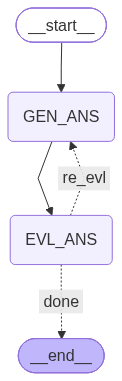

In [16]:
graph.compile()

In [17]:
agent = graph.compile()

In [18]:
intial_state = {
    'question': question,
    'iteration': 0,
    'answer': '',
    'feedback': '',
    'score': 0
}
final_state = agent.invoke(intial_state)

Iteration: 1

Generated Answer: Happy Birthday to all of you! ❤️



c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Score: 5

Feedback: While technically a birthday greeting, addressing 'all of you' is contextually awkward for a general wish and lacks depth or warm well-wishes beyond the bare minimum.

--------------------------------------------------

Iteration: 2

Impoved Answer: Happy Birthday to the people who are you and the friends who make your day shine. 🌟



c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


GoogleRateLimitError: Error calling model 'gemini-3.6-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 41.536097785s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', '

In [ ]:
print(final_state)